<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/UAP_Pola_Chladni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numpy matplotlib scipy Pillow ipywidgets --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import jv, jn_zeros
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

def simulasi_chladni(m, n, resolusi=500):
    zeros = jn_zeros(m, n + 1)
    k     = zeros[n]
    x     = np.linspace(-1, 1, resolusi)
    X, Y  = np.meshgrid(x, x)
    R     = np.sqrt(X**2 + Y**2)
    Theta = np.arctan2(Y, X)
    Z     = jv(m, k * R) * np.cos(m * Theta)
    Z[R > 1.0] = np.nan
    return Z, X, Y

def render_pasir(Z, threshold=0.10):
    pasir = np.where(np.abs(Z) < threshold, 1.0, 0.0)
    pasir[np.isnan(Z)] = np.nan
    return pasir

def estimasi_frekuensi(R_m, h_m, E, rho, nu, m, n):
    D     = (E * h_m**3) / (12 * (1 - nu**2))
    lmn   = jn_zeros(m, n + 1)[n]
    omega = (lmn / R_m)**2 * np.sqrt(D / (rho * h_m))
    return omega / (2 * np.pi)

def crop_square(arr):
    h, w = arr.shape[:2]
    s = min(h, w)
    return arr[(h-s)//2:(h-s)//2+s, (w-s)//2:(w-s)//2+s]

DATA_SAMPEL   = []
PARAM_PLAT    = {}

style  = {'description_width': '160px'}
layout = widgets.Layout(width='360px')

w_diam = widgets.FloatText(value=20.0,  description='Diameter plat (cm):', style=style, layout=layout)
w_tbal = widgets.FloatText(value=1.5,   description='Ketebalan plat (mm):', style=style, layout=layout)
w_mat  = widgets.Dropdown(
    options=['logam', 'akrilik'],
    value='logam',
    description='Material:', style=style, layout=layout
)
btn_plat = widgets.Button(description='Simpan Parameter Plat',
                          button_style='success', layout=widgets.Layout(width='200px'))
out_plat = widgets.Output()

MATERIAL_DB = {
    'logam':      {'E': 200e9, 'rho': 7800, 'nu': 0.29, 'label': 'Logam'},
    'akrilik':   {'E': 3.2e9, 'rho': 1190, 'nu': 0.35, 'label': 'Akrilik'}
}

def simpan_plat(b):
    mat = MATERIAL_DB[w_mat.value]
    PARAM_PLAT.update({
        'D_cm': w_diam.value, 'h_mm': w_tbal.value,
        'R_m':  w_diam.value / 2 / 100,
        'h_m':  w_tbal.value / 1000,
        'E': mat['E'], 'rho': mat['rho'], 'nu': mat['nu'],
        'label': mat['label']
    })
    with out_plat:
        clear_output()
        print(f"   Diameter : {PARAM_PLAT['D_cm']} cm   →   R = {PARAM_PLAT['R_m']*100:.2f} cm")
        print(f"   Ketebalan: {PARAM_PLAT['h_mm']} mm")
        print(f"   Material : {PARAM_PLAT['label']}")
        print(f"   E={PARAM_PLAT['E']:.2e} Pa  ρ={PARAM_PLAT['rho']} kg/m³  ν={PARAM_PLAT['nu']}")

btn_plat.on_click(simpan_plat)

display(widgets.VBox([
    widgets.HTML('<b>Isi dimensi plat yang kamu ukur di lab:</b>'),
    w_diam, w_tbal, w_mat, btn_plat, out_plat
]))

In [2]:
from google.colab import files

print('Upload data pengukuran (JPG/PNG)...')
uploaded = files.upload()

NAMA_FILE_UPLOAD = list(uploaded.keys())
print(f'\n {len(NAMA_FILE_UPLOAD)} foto berhasil diupload:')
for i, f in enumerate(NAMA_FILE_UPLOAD, 1):
    print(f'   {i}. {f}')

Upload data pengukuran (JPG/PNG)...


Saving pola7.jpeg to pola7.jpeg
Saving pola6.jpeg to pola6.jpeg
Saving pola5.jpeg to pola5.jpeg
Saving pola4.jpeg to pola4.jpeg
Saving pola3.jpeg to pola3.jpeg
Saving pola2.jpeg to pola2.jpeg
Saving WhatsApp Image 2026-06-21 at 22.44.43.jpeg to WhatsApp Image 2026-06-21 at 22.44.43.jpeg

 7 foto berhasil diupload:
   1. pola7.jpeg
   2. pola6.jpeg
   3. pola5.jpeg
   4. pola4.jpeg
   5. pola3.jpeg
   6. pola2.jpeg
   7. WhatsApp Image 2026-06-21 at 22.44.43.jpeg


In [3]:
DATA_SAMPEL.clear()
form_rows = []
w_inputs  = []   # simpan referensi widget untuk dibaca saat tombol ditekan

style_sm  = {'description_width': '30px'}
lyt_xs    = widgets.Layout(width='90px')
lyt_md    = widgets.Layout(width='140px')

for fname in NAMA_FILE_UPLOAD:
    try:
        img  = Image.open(fname).convert('RGB')
        arr  = crop_square(np.array(img))
        arr  = Image.fromarray(arr).resize((80, 80))
        import io, base64
        buf  = io.BytesIO()
        arr.save(buf, format='PNG')
        b64  = base64.b64encode(buf.getvalue()).decode()
        thumb_html = f'<img src="data:image/png;base64,{b64}" style="border-radius:6px;"/>'
    except:
        thumb_html = '❌'

    thumb = widgets.HTML(thumb_html)
    label = widgets.HTML(f'<b style="font-size:11px">{fname[:28]}</b>')

    w_m = widgets.IntText(value=0, description='m:', style=style_sm, layout=lyt_xs)
    w_n = widgets.IntText(value=1, description='n:', style=style_sm, layout=lyt_xs)
    w_f = widgets.FloatText(value=0.0, description='f (Hz):', style={'description_width':'50px'}, layout=lyt_md)

    w_inputs.append({'fname': fname, 'w_m': w_m, 'w_n': w_n, 'w_f': w_f})

    row = widgets.HBox([
        thumb,
        widgets.VBox([label,
                      widgets.HBox([w_m, w_n, w_f])],
                     layout=widgets.Layout(margin='0 0 0 12px'))
    ], layout=widgets.Layout(
        border='1px solid #ddd', padding='8px',
        margin='4px 0', border_radius='8px'
    ))
    form_rows.append(row)

btn_simpan = widgets.Button(
    description='Simpan Semua Data & Lanjut',
    button_style='success',
    layout=widgets.Layout(width='260px', margin='10px 0')
)
out_konfirm = widgets.Output()

def simpan_data(b):
    DATA_SAMPEL.clear()
    for row_data in w_inputs:
        DATA_SAMPEL.append({
            'fname':  row_data['fname'],
            'm':      row_data['w_m'].value,
            'n':      row_data['w_n'].value,
            'f_ukur': row_data['w_f'].value,
        })
    with out_konfirm:
        clear_output()
        print(f'  {"No":^4} {"File":^30} {"Mode":^8} {"f Ukur (Hz)":^14}')
        print('-'*60)
        for i, d in enumerate(DATA_SAMPEL, 1):
            print(f'  {i:^4} {d["fname"][:28]:^30} ({d["m"]},{d["n"]}){"":^4} {d["f_ukur"]:^14.1f}')
        print()

btn_simpan.on_click(simpan_data)

display(widgets.VBox([
    widgets.HTML('<b>Isi nilai m, n, dan frekuensi untuk setiap foto:</b><br>'
                 '<small>m = garis diameter &nbsp;|&nbsp; n = lingkaran nodal (tepi luar tidak dihitung)</small>'),
    *form_rows,
    btn_simpan,
    out_konfirm
]))

Generating 7 panel perbandingan...

Sampel 1/7 — Mode (0,2)  f=596.0 Hz


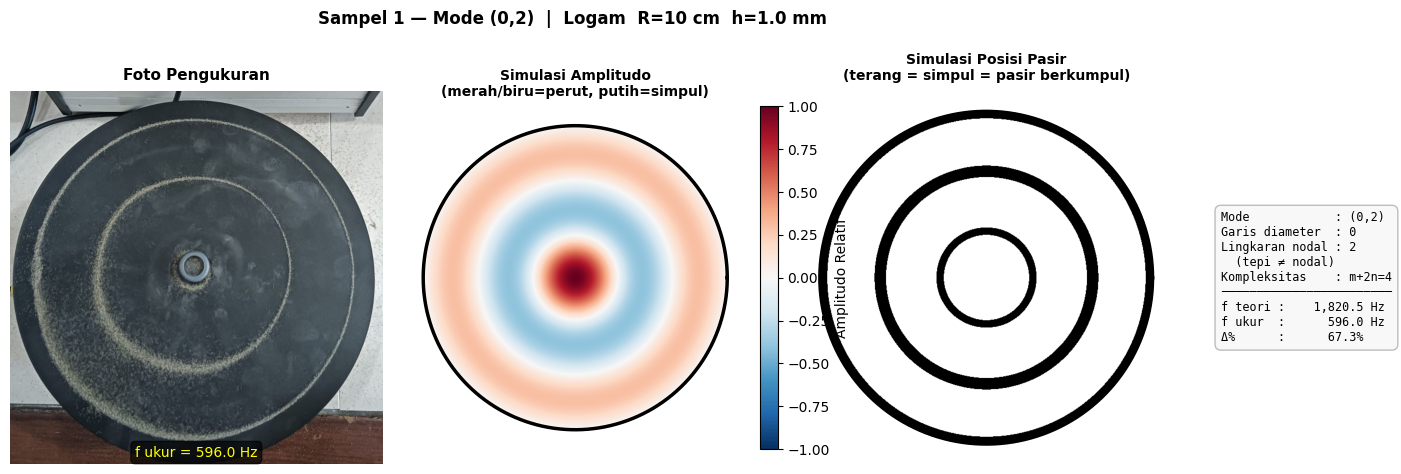

Sampel 2/7 — Mode (2,0)  f=325.0 Hz


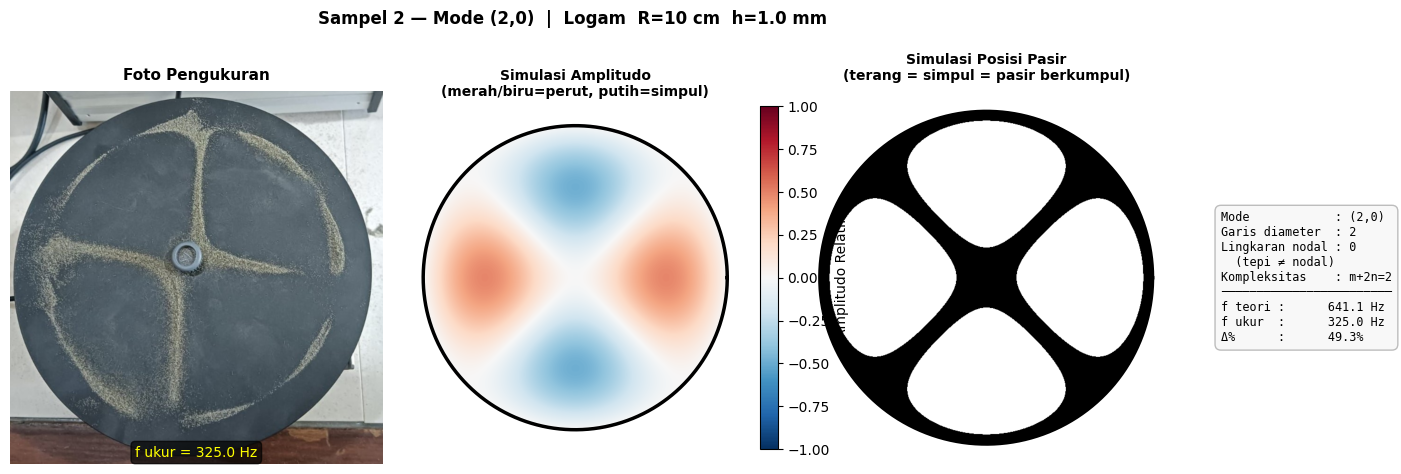

Sampel 3/7 — Mode (0,3)  f=1124.0 Hz


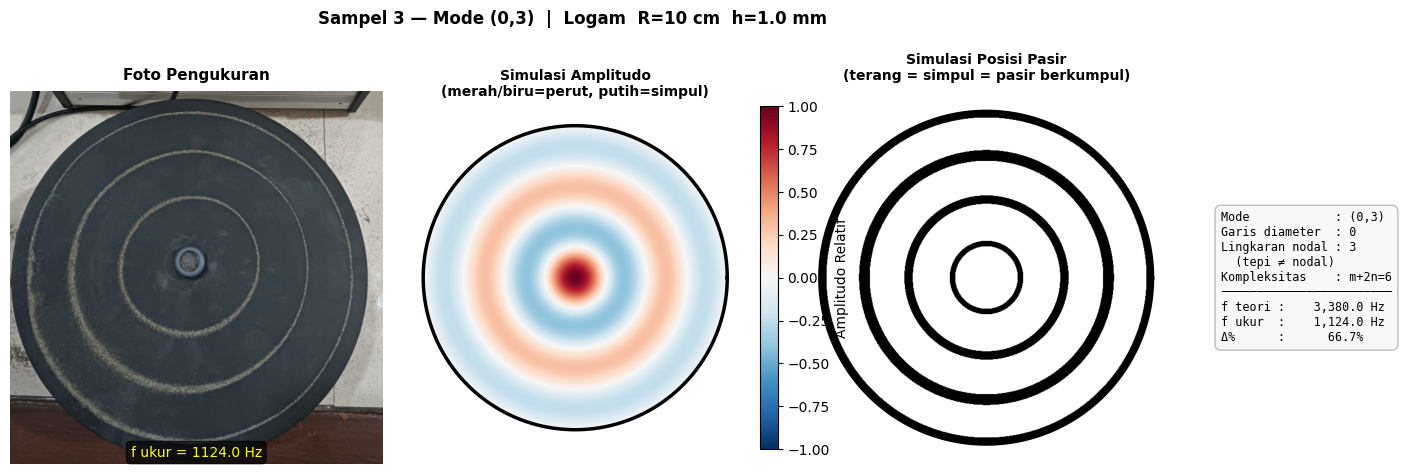

Sampel 4/7 — Mode (3,0)  f=195.8 Hz


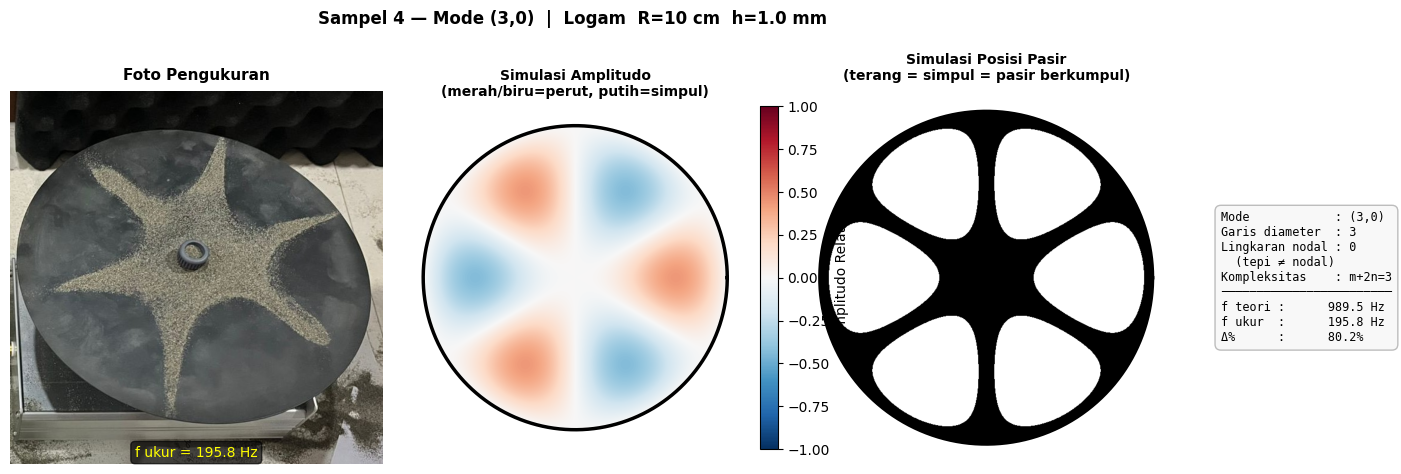

Sampel 5/7 — Mode (0,8)  f=8446.5 Hz


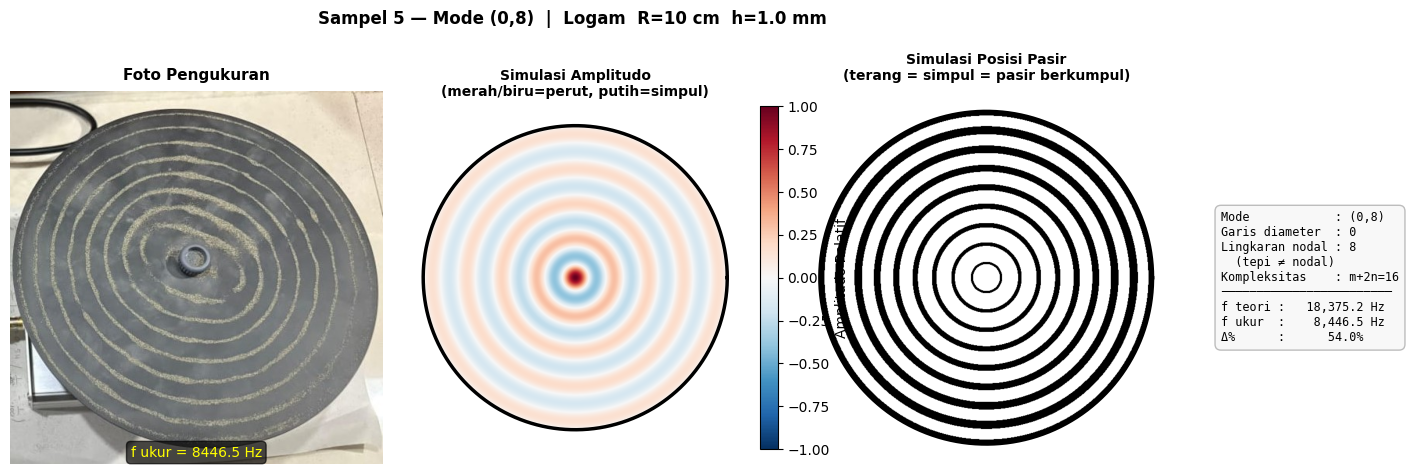

Sampel 6/7 — Mode (0,6)  f=3758.5 Hz


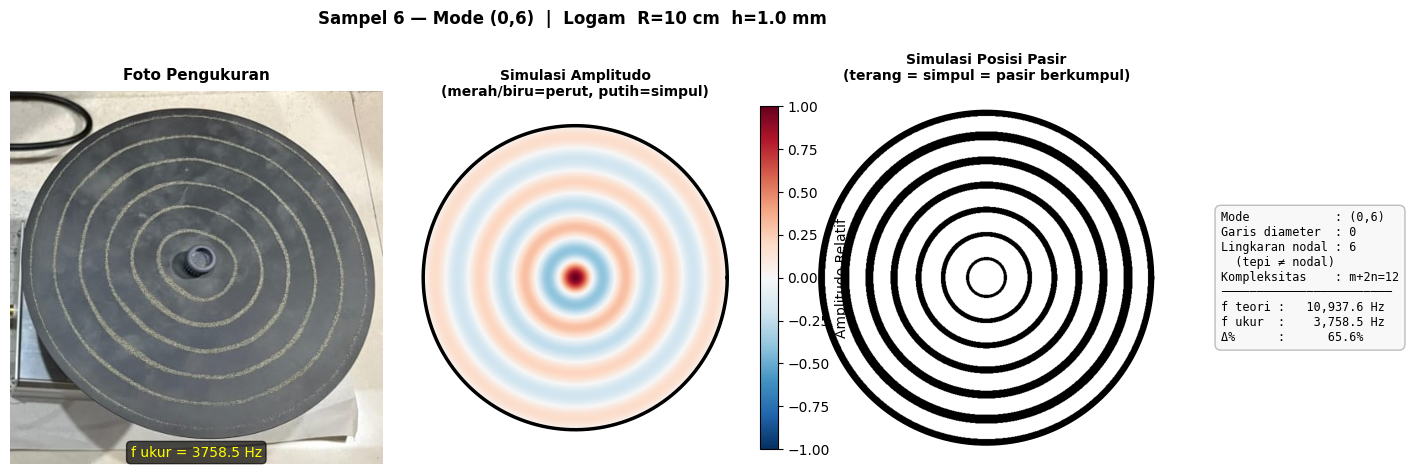

Sampel 7/7 — Mode (0,2)  f=382.4 Hz


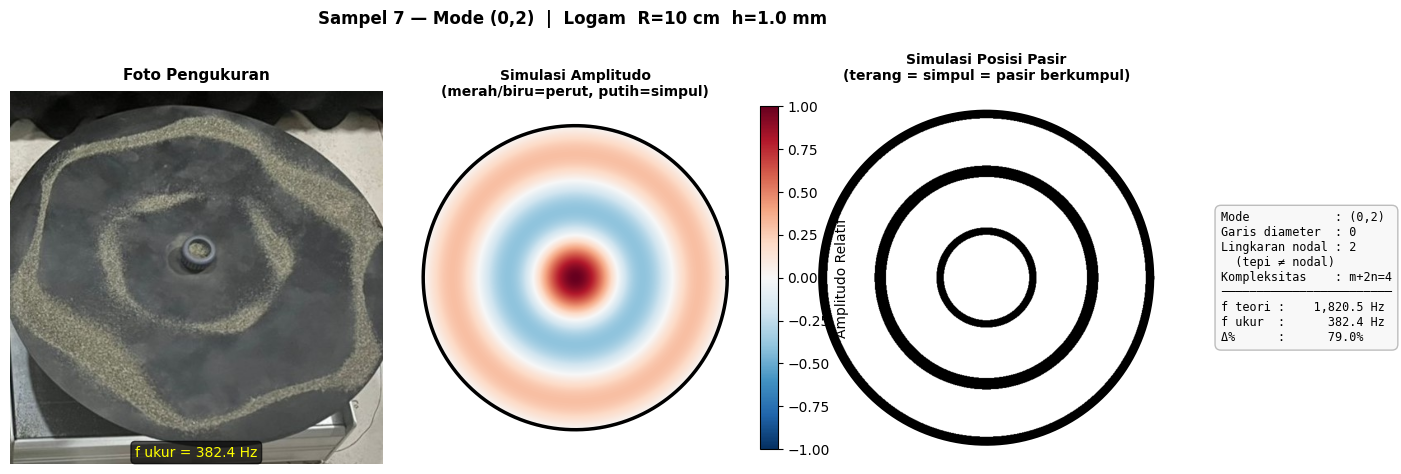

In [4]:
if not DATA_SAMPEL:
    print('Data belum diisi! Jalankan Sel 4 dulu dan klik "Simpan Semua Data".')
elif not PARAM_PLAT:
    print('Parameter plat belum diisi! Jalankan Sel 2 dulu.')
else:
    R_m  = PARAM_PLAT['R_m']
    h_m  = PARAM_PLAT['h_m']
    E    = PARAM_PLAT['E']
    rho  = PARAM_PLAT['rho']
    nu   = PARAM_PLAT['nu']
    mat_label = PARAM_PLAT['label']

    THRESHOLD = 0.10
    RESOLUSI  = 600
    theta_c   = np.linspace(0, 2*np.pi, 500)

    print(f'Generating {len(DATA_SAMPEL)} panel perbandingan...\n')

    for idx, d in enumerate(DATA_SAMPEL, 1):
        fname  = d['fname']
        m, n   = d['m'], d['n']
        f_ukur = d['f_ukur']
        f_t    = estimasi_frekuensi(R_m, h_m, E, rho, nu, m, n)
        delta  = abs(f_t - f_ukur) / f_t * 100 if f_ukur > 0 else 0

        print(f'Sampel {idx}/{len(DATA_SAMPEL)} — Mode ({m},{n})  f={f_ukur} Hz')

        try:
            img_arr = crop_square(np.array(Image.open(fname).convert('RGB')))
            foto_ok = True
        except:
            foto_ok = False

        Z, X, Y = simulasi_chladni(m, n, resolusi=RESOLUSI)
        pasir   = render_pasir(Z, threshold=THRESHOLD)

        fig = plt.figure(figsize=(15, 5.2))
        gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.06)
        ax1, ax2, ax3 = [fig.add_subplot(gs[i]) for i in range(3)]

        if foto_ok:
            ax1.imshow(img_arr)
        else:
            ax1.set_facecolor('#111')
            ax1.text(0.5, 0.5, 'Foto tidak ditemukan', color='red',
                     ha='center', va='center', transform=ax1.transAxes)
        ax1.set_title('Foto Pengukuran', fontsize=11, fontweight='bold', pad=8)
        ax1.axis('off')
        f_str = f'f ukur = {f_ukur} Hz' if f_ukur > 0 else 'f ukur = —'
        ax1.text(0.5, 0.02, f_str, transform=ax1.transAxes,
                 ha='center', fontsize=10, color='yellow',
                 bbox=dict(facecolor='black', alpha=0.65, boxstyle='round,pad=0.3'))

        im2 = ax2.imshow(Z, cmap='RdBu_r', origin='lower',
                         extent=[-1,1,-1,1], vmin=-1, vmax=1)
        ax2.plot(np.cos(theta_c), np.sin(theta_c), 'k-', lw=2.5)
        ax2.set_title('Simulasi Amplitudo\n(merah/biru=perut, putih=simpul)',
                      fontsize=10, fontweight='bold', pad=8)
        ax2.set_xlim(-1.12, 1.12); ax2.set_ylim(-1.12, 1.12)
        ax2.set_aspect('equal'); ax2.axis('off')
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Amplitudo Relatif')

        ax3.imshow(pasir, cmap='bone_r', origin='lower',
                   extent=[-1,1,-1,1], vmin=0, vmax=1)
        ax3.plot(np.cos(theta_c), np.sin(theta_c), 'k-', lw=2.5)
        ax3.set_title('Simulasi Posisi Pasir\n(terang = simpul = pasir berkumpul)',
                      fontsize=10, fontweight='bold', pad=8)
        ax3.set_xlim(-1.12, 1.12); ax3.set_ylim(-1.12, 1.12)
        ax3.set_aspect('equal'); ax3.axis('off')

        info = '\n'.join([
            f'Mode            : ({m},{n})',
            f'Garis diameter  : {m}',
            f'Lingkaran nodal : {n}',
            f'  (tepi ≠ nodal)',
            f'Kompleksitas    : m+2n={m+2*n}',
            f'────────────────────────',
            f'f teori : {f_t:>10,.1f} Hz',
            f'f ukur  : {f_ukur:>10,.1f} Hz',
            f'Δ%      : {delta:>9.1f}%',
        ])
        ax3.text(1.13, 0.5, info, transform=ax3.transAxes,
                 va='center', ha='left', fontsize=8.5, fontfamily='monospace',
                 bbox=dict(facecolor='#f8f8f8', edgecolor='#bbb',
                           boxstyle='round,pad=0.5', alpha=0.97))

        fig.suptitle(
            f'Sampel {idx} — Mode ({m},{n})  |  '
            f'{mat_label}  R={PARAM_PLAT["D_cm"]/2:.0f} cm  h={PARAM_PLAT["h_mm"]:.1f} mm',
            fontsize=12, fontweight='bold', y=1.01)

        plt.tight_layout()
        out_file = f'sampel_{idx}_mode_{m}_{n}.png'
        plt.savefig(out_file, dpi=150, bbox_inches='tight', facecolor='white')
        plt.show()

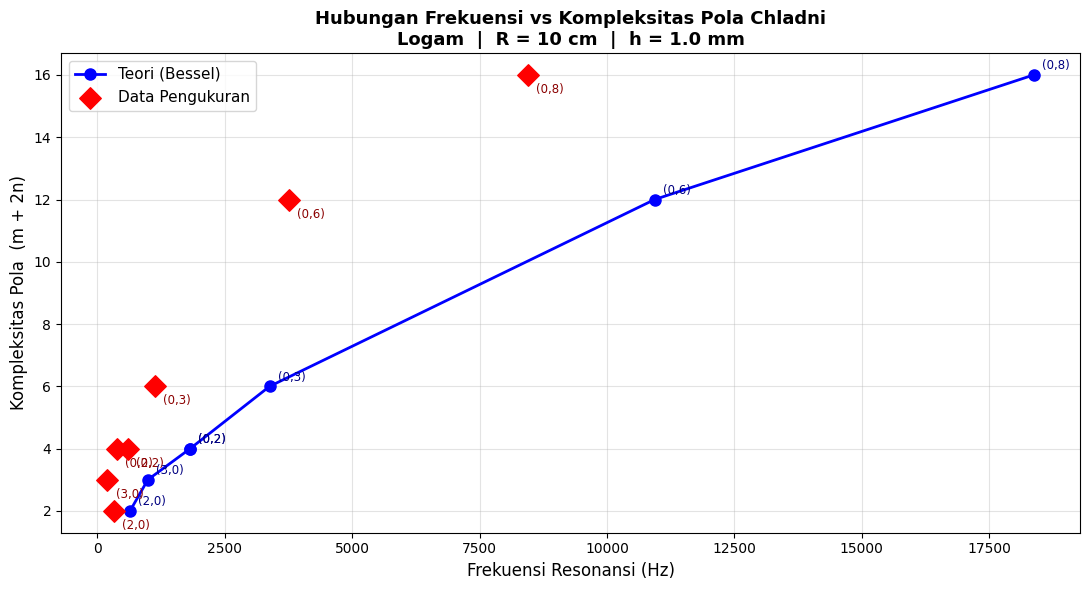

  Tabel Perhitungan 7 DATA
  Logam  |  R=10 cm  |  h=1.0 mm
   No    Mode    m    n    m+2n   f Teori (Hz)   f Ukur (Hz)      Δ%   
------------------------------------------------------------------------------
   1   (0,2)      0    2     4        1820.5         596.0       67.3%  
   2   (2,0)      2    0     2        641.1          325.0       49.3%  
   3   (0,3)      0    3     6        3380.0         1124.0      66.7%  
   4   (3,0)      3    0     3        989.5          195.8       80.2%  
   5   (0,8)      0    8     16      18375.2         8446.5      54.0%  
   6   (0,6)      0    6     12      10937.6         3758.5      65.6%  
   7   (0,2)      0    2     4        1820.5         382.4       79.0%  

  m     = garis nodal diameter
  n     = lingkaran nodal (tepi luar TIDAK dihitung)
  m+2n  = kompleksitas pola
  Δ%    = |f_teori − f_ukur| / f_teori × 100%


In [7]:
if not DATA_SAMPEL or not PARAM_PLAT:
    print('Jalankan Sel 2, 3, 4 dulu!')
else:
    R_m = PARAM_PLAT['R_m']; h_m = PARAM_PLAT['h_m']
    E   = PARAM_PLAT['E'];   rho = PARAM_PLAT['rho']; nu = PARAM_PLAT['nu']

    modes      = [(d['m'], d['n']) for d in DATA_SAMPEL]
    f_ukur_all = [d['f_ukur'] for d in DATA_SAMPEL]
    f_teori_all= [estimasi_frekuensi(R_m, h_m, E, rho, nu, m, n) for m, n in modes]
    kompleks   = [m + 2*n for m, n in modes]
    labels     = [f'({m},{n})' for m, n in modes]

    fig, ax = plt.subplots(figsize=(11, 6))

    idx_sort = np.argsort(f_teori_all)
    ax.plot(np.array(f_teori_all)[idx_sort], np.array(kompleks)[idx_sort],
            'b-o', lw=2, ms=8, label='Teori (Bessel)', zorder=3)

    has_ukur = any(f > 0 for f in f_ukur_all)
    if has_ukur:
        ax.scatter(f_ukur_all, kompleks, color='red', s=120,
                   zorder=5, marker='D', label='Data Pengukuran')

    for ft, fu, k, lbl in zip(f_teori_all, f_ukur_all, kompleks, labels):
        ax.annotate(lbl, xy=(ft, k), xytext=(6, 4),
                    textcoords='offset points', fontsize=8.5, color='navy')
        if fu > 0:
            ax.annotate(lbl, xy=(fu, k), xytext=(6, -13),
                        textcoords='offset points', fontsize=8.5, color='darkred')

    ax.set_xlabel('Frekuensi Resonansi (Hz)', fontsize=12)
    ax.set_ylabel('Kompleksitas Pola  (m + 2n)', fontsize=12)
    ax.set_title(
        f'Hubungan Frekuensi vs Kompleksitas Pola Chladni\n'
        f'{PARAM_PLAT["label"]}  |  '
        f'R = {PARAM_PLAT["D_cm"]/2:.0f} cm  |  h = {PARAM_PLAT["h_mm"]:.1f} mm',
        fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.35)
    ax.yaxis.get_major_locator().set_params(integer=True)
    plt.tight_layout()
    plt.savefig('grafik_frekuensi_vs_kompleksitas.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('='*78)
    print(f'  Tabel Perhitungan {len(DATA_SAMPEL)} DATA')
    print(f'  {PARAM_PLAT["label"]}  |  R={PARAM_PLAT["D_cm"]/2:.0f} cm  |  h={PARAM_PLAT["h_mm"]:.1f} mm')
    print('='*78)
    print(f'  {"No":^4} {"Mode":^8} {"m":^4} {"n":^4} {"m+2n":^6} '
          f'{"f Teori (Hz)":^14} {"f Ukur (Hz)":^14} {"Δ%":^8}')
    print('-'*78)
    for i, (d, ft) in enumerate(zip(DATA_SAMPEL, f_teori_all), 1):
        m, n, fu = d['m'], d['n'], d['f_ukur']
        delta = abs(ft - fu) / ft * 100 if fu > 0 else 0
        fu_str = f'{fu:.1f}' if fu > 0 else '  —  '
        d_str  = f'{delta:.1f}%' if fu > 0 else '  —  '
        print(f'  {i:^4} ({m},{n}){"":^4} {m:^4} {n:^4} {m+2*n:^6} '
              f'{ft:^14.1f} {fu_str:^14} {d_str:^8}')
    print('='*78)
    print('\n  m     = garis nodal diameter')
    print('  n     = lingkaran nodal (tepi luar TIDAK dihitung)')
    print('  m+2n  = kompleksitas pola')
    print('  Δ%    = |f_teori − f_ukur| / f_teori × 100%')

In [8]:
style2 = {'description_width': '30px'}
lyt2   = widgets.Layout(width='120px')

w_em = widgets.IntText(value=2, description='m:', style=style2, layout=lyt2)
w_en = widgets.IntText(value=1, description='n:', style=style2, layout=lyt2)
btn_exp = widgets.Button(description='Tampilkan', button_style='primary',
                         layout=widgets.Layout(width='140px'))
out_exp = widgets.Output()

def run_eksplorasi(b):
    if not PARAM_PLAT:
        with out_exp:
            print('Isi parameter plat di Sel 2 dulu!')
        return
    m_e, n_e = w_em.value, w_en.value
    f_e = estimasi_frekuensi(
        PARAM_PLAT['R_m'], PARAM_PLAT['h_m'],
        PARAM_PLAT['E'], PARAM_PLAT['rho'], PARAM_PLAT['nu'], m_e, n_e)
    Z_e, X_e, Y_e = simulasi_chladni(m_e, n_e, resolusi=500)
    pasir_e = render_pasir(Z_e)
    theta_e = np.linspace(0, 2*np.pi, 500)

    with out_exp:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

        im = axes[0].imshow(Z_e, cmap='RdBu_r', origin='lower',
                            extent=[-1,1,-1,1], vmin=-1, vmax=1)
        axes[0].plot(np.cos(theta_e), np.sin(theta_e), 'k-', lw=2)
        axes[0].set_title('Amplitudo', fontweight='bold'); axes[0].axis('off')
        plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

        axes[1].imshow(pasir_e, cmap='bone_r', origin='lower', extent=[-1,1,-1,1])
        axes[1].plot(np.cos(theta_e), np.sin(theta_e), 'k-', lw=2)
        axes[1].set_title('Posisi Pasir', fontweight='bold'); axes[1].axis('off')

        from mpl_toolkits.mplot3d import Axes3D
        axes[2].remove()
        ax3d = fig.add_subplot(1, 3, 3, projection='3d')
        Z3 = np.nan_to_num(Z_e, nan=0); st = 3
        ax3d.plot_surface(X_e[::st,::st], Y_e[::st,::st], Z3[::st,::st],
                          cmap='RdBu_r', alpha=0.85, linewidth=0)
        ax3d.set_title('3D Amplitudo', fontweight='bold'); ax3d.axis('off')

        fig.suptitle(f'Mode ({m_e},{n_e})  —  f teori ≈ {f_e:.1f} Hz  |  m+2n = {m_e+2*n_e}',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print(f'f teori = {f_e:.2f} Hz  |  kompleksitas = {m_e+2*n_e}')

btn_exp.on_click(run_eksplorasi)

display(widgets.VBox([
    widgets.HTML('<b>Eksplorasi mode (m,n) apapun:</b>'),
    widgets.HBox([w_em, w_en, btn_exp]),
    out_exp
]))